In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "GPU not detected. Stop here and enable a GPU runtime before continuing."
    )

print("GPU runtime verified.")

/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU runtime verified.


In [2]:
!pip install -q keras-cv==0.9.0

In [3]:
!pip install -q --upgrade "protobuf==6.31.1"

In [4]:
import keras
import keras_cv
import google.protobuf

print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)
print("Protobuf:", google.protobuf.__version__)

print("YOLOV8Backbone:", hasattr(keras_cv.models, "YOLOV8Backbone"))
print("YOLOV8Detector:", hasattr(keras_cv.models, "YOLOV8Detector"))

Keras: 3.13.2
KerasCV: 0.9.0
Protobuf: 6.31.1
YOLOV8Backbone: True
YOLOV8Detector: True


In [5]:
import tensorflow as tf
import keras
import keras_cv
import google.protobuf

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("KerasCV    :", keras_cv.__version__)
print("Protobuf   :", google.protobuf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

print("\nChecking YOLOv8 API...")

print(
    "YOLOV8Backbone:",
    hasattr(keras_cv.models, "YOLOV8Backbone")
)

print(
    "YOLOV8Detector:",
    hasattr(keras_cv.models, "YOLOV8Detector")
)

TensorFlow : 2.20.0
Keras      : 3.13.2
KerasCV    : 0.9.0
Protobuf   : 6.31.1
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Checking YOLOv8 API...
YOLOV8Backbone: True
YOLOV8Detector: True


In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/drive/MyDrive/NutriVision")
DATASET_ROOT = PROJECT_ROOT / "foodseg103_yolo"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)

assert PROJECT_ROOT.exists()
assert DATASET_ROOT.exists()

print("Project paths verified.")

PROJECT_ROOT: /content/drive/MyDrive/NutriVision
DATASET_ROOT: /content/drive/MyDrive/NutriVision/foodseg103_yolo
Project paths verified.


In [9]:
from pathlib import Path
import shutil
import time

DRIVE_DATASET = PROJECT_ROOT / "foodseg103_yolo"
LOCAL_DATASET = Path("/content/NutriVision/foodseg103_yolo")

if LOCAL_DATASET.exists():
    print("Removing existing local copy...")
    shutil.rmtree(LOCAL_DATASET)

LOCAL_DATASET.parent.mkdir(parents=True, exist_ok=True)

print("Copying FoodSeg103 YOLO dataset to local Colab storage...")
print("Source:", DRIVE_DATASET)
print("Destination:", LOCAL_DATASET)

start = time.time()

shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)

elapsed = time.time() - start

print(f"\nCopy completed in {elapsed / 60:.2f} minutes.")
print("Local dataset:", LOCAL_DATASET.exists())

Copying FoodSeg103 YOLO dataset to local Colab storage...
Source: /content/drive/MyDrive/NutriVision/foodseg103_yolo
Destination: /content/NutriVision/foodseg103_yolo

Copy completed in 8.34 minutes.
Local dataset: True


In [10]:
from src.detection.dataset import build_dataset

LOCAL_TRAIN_IMAGES = LOCAL_DATASET / "images" / "train"
LOCAL_TRAIN_LABELS = LOCAL_DATASET / "labels" / "train"

train_dataset, train_count, train_steps = build_dataset(
    images_dir=LOCAL_TRAIN_IMAGES,
    labels_dir=LOCAL_TRAIN_LABELS,
    batch_size=4,
    shuffle=True,
    shuffle_buffer=64,   # IMPORTANT: avoid the 1024-image RAM buffer
    augment=False,
)

print("Training dataset created.")
print("Examples:", train_count)
print("Steps per epoch:", train_steps)

Training dataset created.
Examples: 4979
Steps per epoch: 1244


In [11]:
from pathlib import Path
import random
import os

SEED = 42

LOCAL_DATASET = Path("/content/NutriVision/foodseg103_yolo")

SOURCE_IMAGES = LOCAL_DATASET / "images" / "train"
SOURCE_LABELS = LOCAL_DATASET / "labels" / "train"

DEV_ROOT = Path("/content/NutriVision/dev_split")

DEV_TRAIN_IMAGES = DEV_ROOT / "images" / "train"
DEV_TRAIN_LABELS = DEV_ROOT / "labels" / "train"

DEV_VAL_IMAGES = DEV_ROOT / "images" / "val"
DEV_VAL_LABELS = DEV_ROOT / "labels" / "val"

# Clean only the lightweight split directory.
if DEV_ROOT.exists():
    import shutil
    shutil.rmtree(DEV_ROOT)

for path in [
    DEV_TRAIN_IMAGES,
    DEV_TRAIN_LABELS,
    DEV_VAL_IMAGES,
    DEV_VAL_LABELS,
]:
    path.mkdir(parents=True, exist_ok=True)

# Get image filenames only.
image_files = sorted(
    [
        p for p in SOURCE_IMAGES.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
)

if len(image_files) != 4979:
    raise RuntimeError(
        f"Expected 4979 training images, found {len(image_files)}."
    )

# Deterministic 90/10 split.
rng = random.Random(SEED)
rng.shuffle(image_files)

split_index = int(len(image_files) * 0.90)

dev_train_files = image_files[:split_index]
dev_val_files = image_files[split_index:]

def create_linked_split(files, image_dest, label_dest):
    for image_path in files:
        label_path = SOURCE_LABELS / f"{image_path.stem}.txt"

        if not label_path.exists():
            raise FileNotFoundError(
                f"Missing label for {image_path.name}"
            )

        # Symlink: no second image copy is created.
        os.symlink(image_path, image_dest / image_path.name)
        os.symlink(label_path, label_dest / label_path.name)

create_linked_split(
    dev_train_files,
    DEV_TRAIN_IMAGES,
    DEV_TRAIN_LABELS,
)

create_linked_split(
    dev_val_files,
    DEV_VAL_IMAGES,
    DEV_VAL_LABELS,
)

print("Development split created.")
print("Seed:", SEED)
print("Dev-train:", len(dev_train_files))
print("Dev-val  :", len(dev_val_files))
print("Final test remains:", 2135)

Development split created.
Seed: 42
Dev-train: 4481
Dev-val  : 498
Final test remains: 2135


In [12]:
from src.detection.dataset import build_dataset

DEV_TRAIN_DATASET, DEV_TRAIN_COUNT, DEV_TRAIN_STEPS = build_dataset(
    images_dir=DEV_TRAIN_IMAGES,
    labels_dir=DEV_TRAIN_LABELS,
    batch_size=4,
    shuffle=True,
    shuffle_buffer=64,
    augment=False,
)

DEV_VAL_DATASET, DEV_VAL_COUNT, DEV_VAL_STEPS = build_dataset(
    images_dir=DEV_VAL_IMAGES,
    labels_dir=DEV_VAL_LABELS,
    batch_size=4,
    shuffle=False,
    shuffle_buffer=1,
    augment=False,
)

print("Dev-train:")
print("  examples:", DEV_TRAIN_COUNT)
print("  steps   :", DEV_TRAIN_STEPS)

print("\nDev-val:")
print("  examples:", DEV_VAL_COUNT)
print("  steps   :", DEV_VAL_STEPS)

Dev-train:
  examples: 4481
  steps   : 1120

Dev-val:
  examples: 498
  steps   : 124


In [13]:
from src.detection.model import build_yolov8_detector

detector = build_yolov8_detector()

print("Model created successfully.")
print("Model type:", type(detector).__name__)
print("Trainable parameters:", detector.count_params())

100%|██████████| 646/646 [00:00<00:00, 595kB/s]


Model created successfully.
Model type: YOLOV8Detector
Trainable parameters: 12836949


In [15]:
from src.detection.model import (
    build_yolov8_detector,
    set_backbone_trainable,
    recompile_for_finetuning,
)

# Fresh model — discard all smoke-test weights.
detector = build_yolov8_detector()

# Phase 1: freeze the pretrained COCO backbone.
set_backbone_trainable(detector, trainable=False)

# Phase 1 learning rate.
recompile_for_finetuning(
    detector,
    learning_rate=1e-3,
)

print("Fresh Phase 1 model ready.")
print("Smoke-test weights discarded.")
print("Backbone frozen.")
print("Learning rate: 1e-3")

Fresh Phase 1 model ready.
Smoke-test weights discarded.
Backbone frozen.
Learning rate: 1e-3


In [17]:
print("Testing dataset re-iteration...")

for epoch in range(2):
    iterator = iter(DEV_TRAIN_DATASET)

    for step in range(10):
        images, bboxes = next(iterator)

    print(
        f"Epoch-like pass {epoch + 1}/2: PASS — "
        f"10 batches retrieved successfully"
    )

print("DATASET RE-ITERATION TEST PASSED")

Testing dataset re-iteration...
Epoch-like pass 1/2: PASS — 10 batches retrieved successfully
Epoch-like pass 2/2: PASS — 10 batches retrieved successfully
DATASET RE-ITERATION TEST PASSED


In [18]:
import math

SMOKE_STEPS = 10
SMOKE_EPOCHS = 2

print(f"Running Keras smoke test: {SMOKE_EPOCHS} epochs × {SMOKE_STEPS} steps")

smoke_history = detector.fit(
    DEV_TRAIN_DATASET,
    steps_per_epoch=SMOKE_STEPS,
    epochs=SMOKE_EPOCHS,
    verbose=1,
)

losses = smoke_history.history.get("loss", [])

print("Smoke-test losses:", losses)

assert len(losses) == SMOKE_EPOCHS, (
    f"Expected {SMOKE_EPOCHS} completed epochs, got {len(losses)}"
)
assert all(math.isfinite(x) for x in losses), "NaN/Inf loss detected"
assert all(x > 0 for x in losses), "Unexpected zero loss detected"

print("SMOKE TEST PASSED")

Running Keras smoke test: 2 epochs × 10 steps
Epoch 1/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 341ms/step - box_loss: 1.6044 - class_loss: 0.1627 - loss: 1.7671
Epoch 2/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 376ms/step - box_loss: 1.6395 - class_loss: 0.1618 - loss: 1.8013
Smoke-test losses: [1.7670819759368896, 1.801337480545044]
SMOKE TEST PASSED


In [19]:
from src.detection.model import (
    build_yolov8_detector,
    set_backbone_trainable,
    recompile_for_finetuning,
)

detector = build_yolov8_detector()

set_backbone_trainable(detector, trainable=False)

recompile_for_finetuning(
    detector,
    learning_rate=1e-3,
)

print("Fresh Phase 1 model ready.")

Fresh Phase 1 model ready.


In [21]:
# Stage 5 only: make the finite datasets reusable across epochs.
# Stage 4 dataset.py is NOT modified.

DEV_TRAIN_DATASET = DEV_TRAIN_DATASET.repeat()
DEV_VAL_DATASET = DEV_VAL_DATASET.repeat()

print("Training dataset cardinality:",
      tf.data.experimental.cardinality(DEV_TRAIN_DATASET).numpy())

print("Validation dataset cardinality:",
      tf.data.experimental.cardinality(DEV_VAL_DATASET).numpy())

assert tf.data.experimental.cardinality(DEV_TRAIN_DATASET).numpy() == -1
assert tf.data.experimental.cardinality(DEV_VAL_DATASET).numpy() == -1

print("REPEATING DATASETS READY")

Training dataset cardinality: -1
Validation dataset cardinality: -1
REPEATING DATASETS READY


In [22]:
from src.detection.model import (
    build_yolov8_detector,
    set_backbone_trainable,
    recompile_for_finetuning,
)

detector = build_yolov8_detector()

set_backbone_trainable(detector, trainable=False)

recompile_for_finetuning(
    detector,
    learning_rate=1e-3,
)

print("Fresh Phase 1 model ready.")

Fresh Phase 1 model ready.


In [23]:
from pathlib import Path

CHECKPOINT_DIR = Path("/content/NutriVision/training/yolov8_stage5")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

PHASE1_WEIGHTS = CHECKPOINT_DIR / "phase1.weights.h5"

phase1_history = detector.fit(
    DEV_TRAIN_DATASET,
    validation_data=DEV_VAL_DATASET,
    steps_per_epoch=1120,
    validation_steps=124,
    epochs=8,
    verbose=1,
)

detector.save_weights(PHASE1_WEIGHTS)

print("Phase 1 complete.")
print("Weights saved to:", PHASE1_WEIGHTS)

Epoch 1/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 332s 273ms/step - box_loss: 1.8759 - class_loss: 23.4023 - loss: 25.2782 - val_box_loss: 1.8164 - val_class_loss: 0.2429 - val_loss: 2.0593
Epoch 2/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 302s 270ms/step - box_loss: 1.6814 - class_loss: 0.1904 - loss: 1.8719 - val_box_loss: 1.6720 - val_class_loss: 0.1796 - val_loss: 1.8516
Epoch 3/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 301s 269ms/step - box_loss: 1.5983 - class_loss: 0.1597 - loss: 1.7580 - val_box_loss: 1.6017 - val_class_loss: 0.1606 - val_loss: 1.7622
Epoch 4/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 302s 269ms/step - box_loss: 1.4971 - class_loss: 0.1477 - loss: 1.6448 - val_box_loss: 1.5283 - val_class_loss: 0.1545 - val_loss: 1.6828
Epoch 5/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 295s 263ms/step - box_loss: 1.4167 - class_loss: 0.1398 - loss: 1.5564 - val_box_loss: 1.4891 - val_class_loss: 0.1457 - val_loss: 1.6348
Epoch 6/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 318s 284ms/step - box_loss: 1.3427 - class_loss: 0.1335 - loss

In [27]:
import numpy as np
def compute_iou_matrix(boxes_a, boxes_b):
    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)), dtype=np.float32)

    boxes_a = np.array(boxes_a, dtype=np.float32)
    boxes_b = np.array(boxes_b, dtype=np.float32)

    x1 = np.maximum(boxes_a[:, None, 0], boxes_b[None, :, 0])
    y1 = np.maximum(boxes_a[:, None, 1], boxes_b[None, :, 1])
    x2 = np.minimum(boxes_a[:, None, 2], boxes_b[None, :, 2])
    y2 = np.minimum(boxes_a[:, None, 3], boxes_b[None, :, 3])

    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter = inter_w * inter_h

    area_a = (
        np.clip(boxes_a[:, 2] - boxes_a[:, 0], 0, None)
        * np.clip(boxes_a[:, 3] - boxes_a[:, 1], 0, None)
    )
    area_b = (
        np.clip(boxes_b[:, 2] - boxes_b[:, 0], 0, None)
        * np.clip(boxes_b[:, 3] - boxes_b[:, 1], 0, None)
    )

    union = area_a[:, None] + area_b[None, :] - inter

    return np.where(union > 0, inter / union, 0.0)


def match_predictions_to_gt(
    pred_boxes,
    pred_classes,
    pred_scores,
    gt_boxes,
    gt_classes,
    iou_threshold=0.5,
):
    order = (
        np.argsort(-np.array(pred_scores))
        if len(pred_scores)
        else np.array([], dtype=int)
    )

    matched_gt = set()
    tp = 0
    fp = 0

    for idx in order:
        p_box = pred_boxes[idx]
        p_cls = pred_classes[idx]

        best_iou = 0.0
        best_gt_idx = -1

        for gt_idx, (g_box, g_cls) in enumerate(zip(gt_boxes, gt_classes)):
            if gt_idx in matched_gt or g_cls != p_cls:
                continue

            iou = compute_iou_matrix([p_box], [g_box])[0, 0]

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold and best_gt_idx >= 0:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)

    return tp, fp, fn


def evaluate_dataset(
    model,
    dataset,
    steps,
    iou_threshold=0.5,
    diagnostic_conf_threshold=None,
):
    total_tp = 0
    total_fp = 0
    total_fn = 0

    all_confidences = []
    per_class_counts = {}

    original_decoder = getattr(model, "prediction_decoder", None)

    if diagnostic_conf_threshold is not None and original_decoder is not None:
        try:
            original_decoder.confidence_threshold = diagnostic_conf_threshold
        except Exception as e:
            print("Could not override confidence threshold on decoder:", e)

    iterator = iter(dataset)

    for step in range(steps):
        batch = next(iterator)

        images = (
            batch["images"]
            if isinstance(batch, dict)
            else batch[0]
        )

        gt_boxes_batch = (
            batch["bounding_boxes"]["boxes"]
            if isinstance(batch, dict)
            else batch[1]["boxes"]
        )

        gt_classes_batch = (
            batch["bounding_boxes"]["classes"]
            if isinstance(batch, dict)
            else batch[1]["classes"]
        )

        preds = model.predict(images, verbose=0)

        pred_boxes = np.array(preds["boxes"])
        pred_classes = np.array(preds["classes"])
        pred_conf = np.array(preds["confidence"])
        num_det = np.array(preds["num_detections"])

        for i in range(images.shape[0]):
            n = int(num_det[i])

            p_boxes_i = pred_boxes[i, :n]
            p_classes_i = pred_classes[i, :n]
            p_conf_i = pred_conf[i, :n]

            all_confidences.extend(p_conf_i.tolist())

            for c in p_classes_i:
                per_class_counts[int(c)] = (
                    per_class_counts.get(int(c), 0) + 1
                )

            gt_c = np.array(gt_classes_batch[i])
            valid_mask = gt_c >= 0

            g_boxes_i = np.array(gt_boxes_batch[i])[valid_mask]
            g_classes_i = gt_c[valid_mask]

            tp, fp, fn = match_predictions_to_gt(
                p_boxes_i,
                p_classes_i,
                p_conf_i,
                g_boxes_i,
                g_classes_i,
                iou_threshold,
            )

            total_tp += tp
            total_fp += fp
            total_fn += fn

    if diagnostic_conf_threshold is not None and original_decoder is not None:
        try:
            original_decoder.confidence_threshold = (
                original_decoder.confidence_threshold
            )
        except Exception:
            pass

    precision = (
        total_tp / (total_tp + total_fp)
        if (total_tp + total_fp) > 0
        else 0.0
    )

    recall = (
        total_tp / (total_tp + total_fn)
        if (total_tp + total_fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou_threshold": iou_threshold,
        "diagnostic_conf_threshold_used": diagnostic_conf_threshold,
        "confidence_stats": {
            "count": len(all_confidences),
            "mean": (
                float(np.mean(all_confidences))
                if all_confidences
                else 0.0
            ),
            "max": (
                float(np.max(all_confidences))
                if all_confidences
                else 0.0
            ),
        },
        "unique_predicted_classes": len(per_class_counts),
        "per_class_prediction_counts": per_class_counts,
    }


print(
    "Evaluation functions defined "
    "(IoU matching is class-aware, one-to-one, official predict() only)."
)

Evaluation functions defined (IoU matching is class-aware, one-to-one, official predict() only).


In [28]:
dev_eval_results = evaluate_dataset(
    detector,
    DEV_VAL_DATASET,
    DEV_VAL_STEPS,
    iou_threshold=0.5,
)

print(
    "DEVELOPMENT VALIDATION RESULTS "
    "(IoU >= 0.5, official decoder, default threshold):"
)

for k, v in dev_eval_results.items():
    if k != "per_class_prediction_counts":
        print(" ", k, ":", v)

DEVELOPMENT VALIDATION RESULTS (IoU >= 0.5, official decoder, default threshold):
  tp : 58
  fp : 83
  fn : 1773
  precision : 0.41134751773049644
  recall : 0.031676679410158386
  f1 : 0.058823529411764705
  iou_threshold : 0.5
  diagnostic_conf_threshold_used : None
  confidence_stats : {'count': 141, 'mean': 0.32551256498546466, 'max': 0.7726220488548279}
  unique_predicted_classes : 7


In [29]:
dev_eval_diag = evaluate_dataset(
    detector,
    DEV_VAL_DATASET,
    DEV_VAL_STEPS,
    iou_threshold=0.5,
    diagnostic_conf_threshold=0.05,
)

print()
print(
    "DIAGNOSTIC-ONLY RESULTS "
    "(confidence_threshold=0.05, NOT the production setting):"
)

for k, v in dev_eval_diag.items():
    if k != "per_class_prediction_counts":
        print(" ", k, ":", v)


DIAGNOSTIC-ONLY RESULTS (confidence_threshold=0.05, NOT the production setting):
  tp : 58
  fp : 83
  fn : 1773
  precision : 0.41134751773049644
  recall : 0.031676679410158386
  f1 : 0.058823529411764705
  iou_threshold : 0.5
  diagnostic_conf_threshold_used : 0.05
  confidence_stats : {'count': 141, 'mean': 0.32551256498546466, 'max': 0.7726220488548279}
  unique_predicted_classes : 7


In [30]:
from src.detection.model import (
    build_yolov8_detector,
    set_backbone_trainable,
    recompile_for_finetuning,
)

detector = build_yolov8_detector()

set_backbone_trainable(detector, trainable=True)

recompile_for_finetuning(
    detector,
    learning_rate=1e-4,
)

print("Fresh Phase 2 model ready.")

Fresh Phase 2 model ready.


In [31]:
PHASE1_WEIGHTS = "/content/NutriVision/training/yolov8_stage5/phase1.weights.h5"

detector.load_weights(PHASE1_WEIGHTS)

print("Phase 1 weights loaded.")

Phase 1 weights loaded.


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 230 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [33]:
dev_batch = next(iter(DEV_VAL_DATASET))

dev_images = dev_batch[0]
dev_gt = dev_batch[1]

print("Images:", dev_images.shape)
print("GT boxes:", dev_gt["boxes"].shape)
print("GT classes:", dev_gt["classes"].shape)

Images: (4, 640, 640, 3)
GT boxes: (4, 32, 4)
GT classes: (4, 32)


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualize_predictions(
    model,
    images,
    gt_boxes_batch,
    gt_classes_batch,
    class_mapping,
    n=4,
    title="",
):
    preds = model.predict(images[:n], verbose=0)

    pred_boxes = np.array(preds["boxes"])
    pred_classes = np.array(preds["classes"])
    pred_conf = np.array(preds["confidence"])
    num_det = np.array(preds["num_detections"])

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    fig.suptitle(title)

    for i, ax in enumerate(axes):
        image = images[i].numpy() if hasattr(images[i], "numpy") else images[i]

        ax.imshow(image.astype(np.uint8))

        # -------------------------
        # Ground-truth boxes
        # -------------------------
        gt_boxes = gt_boxes_batch["boxes"][i]
        gt_classes = gt_classes_batch["classes"][i]

        if hasattr(gt_boxes, "numpy"):
            gt_boxes = gt_boxes.numpy()

        if hasattr(gt_classes, "numpy"):
            gt_classes = gt_classes.numpy()

        for box, cls_id in zip(gt_boxes, gt_classes):

            # Ignore padded boxes
            if np.allclose(box, 0):
                continue

            x1, y1, x2, y2 = box

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor="lime",
            )
            ax.add_patch(rect)

            label = class_mapping.get(
                str(int(cls_id)),
                class_mapping.get(int(cls_id), str(int(cls_id))),
            )

            ax.text(
                x1,
                max(0, y1 - 3),
                f"GT: {label}",
                fontsize=8,
                color="lime",
                backgroundcolor="black",
            )

        # -------------------------
        # Predictions
        # -------------------------
        count = int(num_det[i])

        for j in range(count):
            box = pred_boxes[i, j]
            cls_id = int(pred_classes[i, j])
            conf = float(pred_conf[i, j])

            x1, y1, x2, y2 = box

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor="red",
            )
            ax.add_patch(rect)

            label = class_mapping.get(
                str(cls_id),
                class_mapping.get(cls_id, str(cls_id)),
            )

            ax.text(
                x1,
                min(image.shape[0] - 5, y2 + 12),
                f"P: {label} {conf:.2f}",
                fontsize=8,
                color="red",
                backgroundcolor="black",
            )

        ax.set_title(f"Image {i} | detections: {count}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualize_predictions(
    model,
    images,
    gt_batch,
    n=4,
    title="",
):
    preds = model.predict(images[:n], verbose=0)

    pred_boxes = np.array(preds["boxes"])
    pred_classes = np.array(preds["classes"])
    pred_conf = np.array(preds["confidence"])
    num_det = np.array(preds["num_detections"])

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    fig.suptitle(title)

    for i, ax in enumerate(axes):

        image = images[i]
        if hasattr(image, "numpy"):
            image = image.numpy()

        ax.imshow(image.astype(np.uint8))

        # -------------------------
        # Ground truth
        # -------------------------
        gt_boxes = gt_batch["boxes"][i]
        gt_classes = gt_batch["classes"][i]

        if hasattr(gt_boxes, "numpy"):
            gt_boxes = gt_boxes.numpy()

        if hasattr(gt_classes, "numpy"):
            gt_classes = gt_classes.numpy()

        for box, cls_id in zip(gt_boxes, gt_classes):

            # Ignore padding
            if np.allclose(box, 0):
                continue

            x1, y1, x2, y2 = box

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor="lime",
            )
            ax.add_patch(rect)

            ax.text(
                x1,
                max(0, y1 - 3),
                f"GT class {int(cls_id)}",
                fontsize=8,
                color="lime",
                backgroundcolor="black",
            )

        # -------------------------
        # Predictions
        # -------------------------
        count = int(num_det[i])

        for j in range(count):

            box = pred_boxes[i, j]
            cls_id = int(pred_classes[i, j])
            conf = float(pred_conf[i, j])

            x1, y1, x2, y2 = box

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor="red",
            )
            ax.add_patch(rect)

            ax.text(
                x1,
                min(image.shape[0] - 5, y2 + 12),
                f"P class {cls_id} ({conf:.2f})",
                fontsize=8,
                color="red",
                backgroundcolor="black",
            )

        ax.set_title(f"Image {i} | detections: {count}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

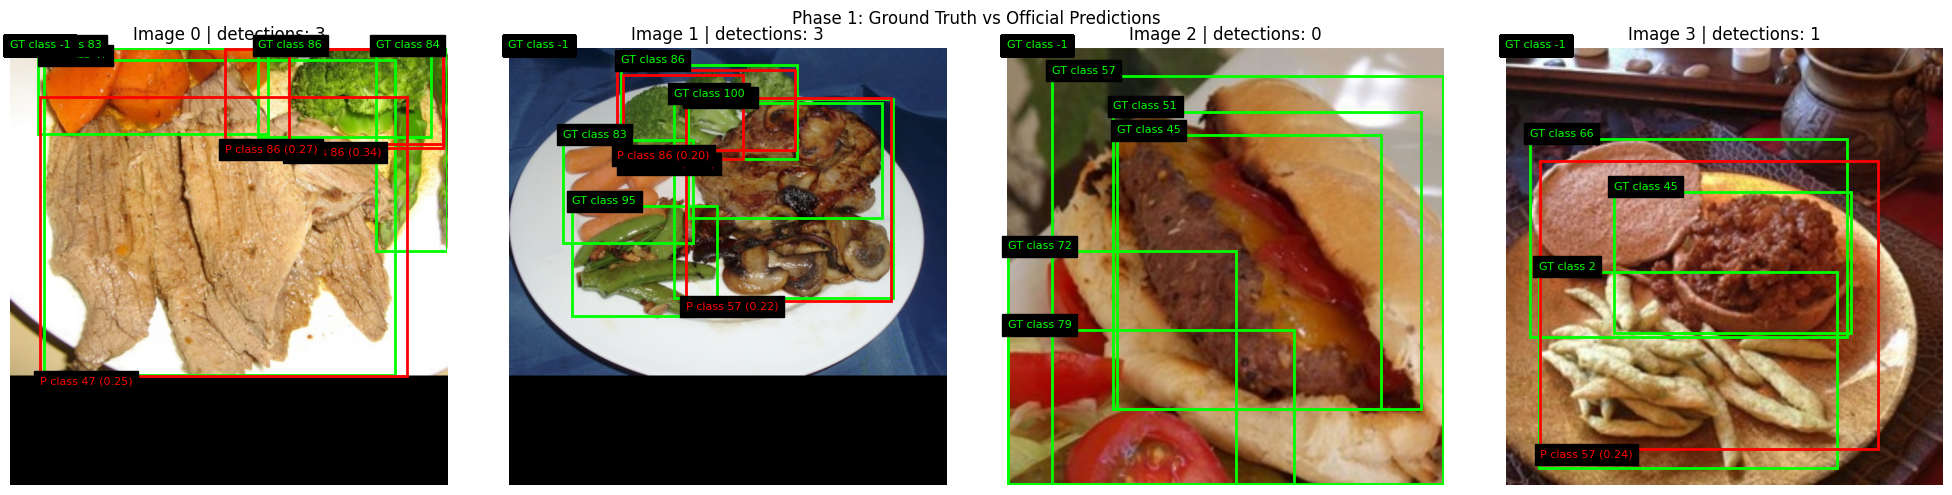

In [43]:
visualize_predictions(
    detector,
    dev_images,
    dev_gt,
    n=4,
    title="Phase 1: Ground Truth vs Official Predictions",
)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualize_predictions(
    model,
    images,
    gt_batch,
    n=4,
    title="",
):
    preds = model.predict(images[:n], verbose=0)

    pred_boxes = np.array(preds["boxes"])
    pred_classes = np.array(preds["classes"])
    pred_conf = np.array(preds["confidence"])
    num_det = np.array(preds["num_detections"])

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    fig.suptitle(title)

    for i, ax in enumerate(axes):

        image = images[i]
        if hasattr(image, "numpy"):
            image = image.numpy()

        ax.imshow(image.astype(np.uint8))

        # -------------------------
        # Ground-truth boxes
        # -------------------------
        gt_boxes = gt_batch["boxes"][i]
        gt_classes = gt_batch["classes"][i]

        if hasattr(gt_boxes, "numpy"):
            gt_boxes = gt_boxes.numpy()

        if hasattr(gt_classes, "numpy"):
            gt_classes = gt_classes.numpy()

        for box, cls_id in zip(gt_boxes, gt_classes):

            # Ignore padded entries
            if cls_id < 0:
                continue

            if np.allclose(box, 0):
                continue

            x1, y1, x2, y2 = box

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor="lime",
            )
            ax.add_patch(rect)

            ax.text(
                x1,
                max(0, y1 - 3),
                f"GT class {int(cls_id)}",
                fontsize=8,
                color="lime",
                backgroundcolor="black",
            )

        # -------------------------
        # Predictions
        # -------------------------
        count = int(num_det[i])

        for j in range(count):

            box = pred_boxes[i, j]
            cls_id = int(pred_classes[i, j])
            conf = float(pred_conf[i, j])

            x1, y1, x2, y2 = box

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor="red",
            )
            ax.add_patch(rect)

            ax.text(
                x1,
                min(image.shape[0] - 5, y2 + 12),
                f"P class {cls_id} ({conf:.2f})",
                fontsize=8,
                color="red",
                backgroundcolor="black",
            )

        ax.set_title(f"Image {i} | detections: {count}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

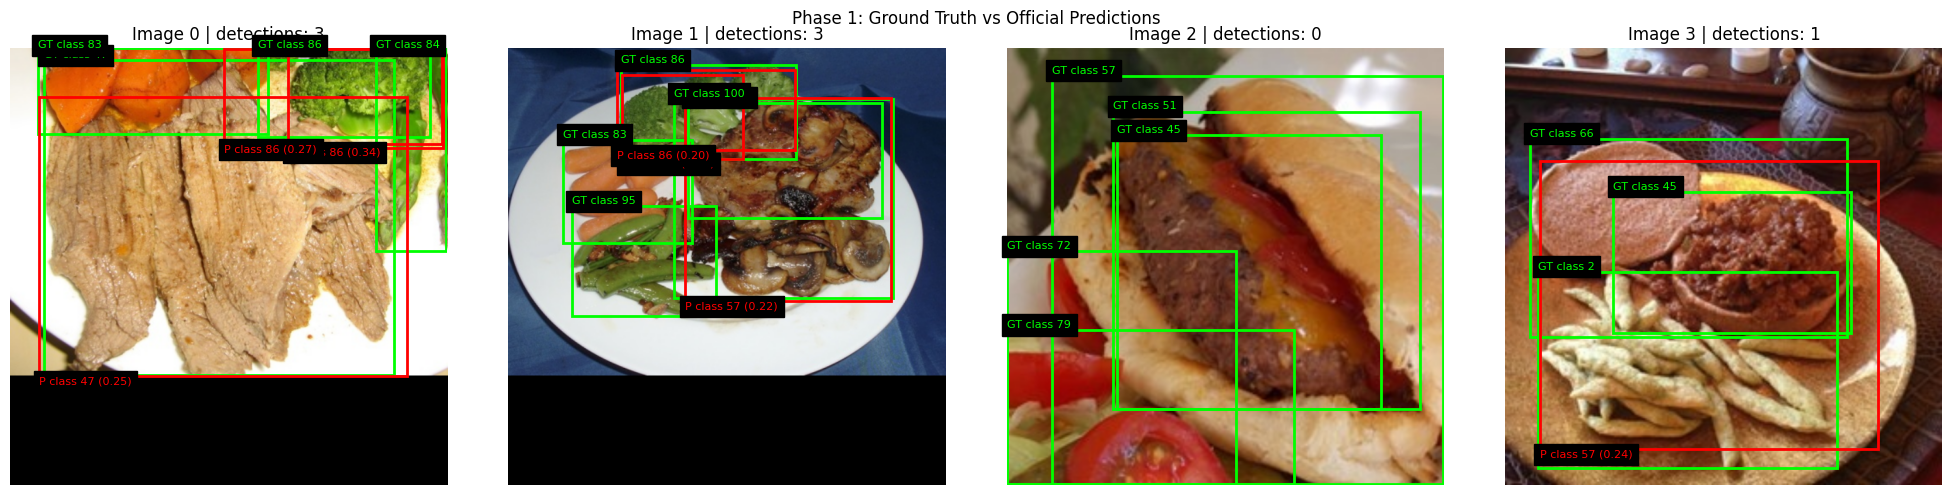

In [45]:
visualize_predictions(
    detector,
    dev_images,
    dev_gt,
    n=4,
    title="Phase 1: Ground Truth vs Official Predictions",
)

In [46]:
import json
from pathlib import Path

ARTIFACT_DIR = Path("/content/NutriVision/training/yolov8_stage5")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save evaluation results
with open(ARTIFACT_DIR / "phase1_eval_results.json", "w") as f:
    json.dump(dev_eval_results, f, indent=2)

# Save training history
with open(ARTIFACT_DIR / "phase1_history.json", "w") as f:
    json.dump(phase1_history.history, f, indent=2)

print("Saved:")
print(ARTIFACT_DIR / "phase1.weights.h5")
print(ARTIFACT_DIR / "phase1_eval_results.json")
print(ARTIFACT_DIR / "phase1_history.json")

Saved:
/content/NutriVision/training/yolov8_stage5/phase1.weights.h5
/content/NutriVision/training/yolov8_stage5/phase1_eval_results.json
/content/NutriVision/training/yolov8_stage5/phase1_history.json


In [47]:
# Fresh model from completed Phase 1 checkpoint
detector = build_yolov8_detector()

detector.load_weights(
    "/content/NutriVision/training/yolov8_stage5/phase1.weights.h5"
)

# Unfreeze backbone for fine-tuning
set_backbone_trainable(detector, trainable=True)

# Lower LR for fine-tuning
recompile_for_finetuning(
    detector,
    learning_rate=1e-4
)

print("Phase 2 model ready.")

Phase 2 model ready.


In [48]:
phase2_history = detector.fit(
    DEV_TRAIN_DATASET,
    validation_data=DEV_VAL_DATASET,
    steps_per_epoch=DEV_TRAIN_STEPS,
    validation_steps=DEV_VAL_STEPS,
    epochs=8,
    verbose=1,
)

Epoch 1/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 448s 365ms/step - box_loss: 1.3011 - class_loss: 0.1313 - loss: 1.4325 - val_box_loss: 1.2703 - val_class_loss: 0.1314 - val_loss: 1.4016
Epoch 2/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 412s 368ms/step - box_loss: 1.1557 - class_loss: 0.1248 - loss: 1.2804 - val_box_loss: 1.2010 - val_class_loss: 0.1281 - val_loss: 1.3291
Epoch 3/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 409s 365ms/step - box_loss: 1.0694 - class_loss: 0.1215 - loss: 1.1908 - val_box_loss: 1.1923 - val_class_loss: 0.1277 - val_loss: 1.3200
Epoch 4/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 409s 365ms/step - box_loss: 1.0108 - class_loss: 0.1188 - loss: 1.1296 - val_box_loss: 1.1742 - val_class_loss: 0.1245 - val_loss: 1.2987
Epoch 5/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 402s 359ms/step - box_loss: 0.9524 - class_loss: 0.1164 - loss: 1.0687 - val_box_loss: 1.1866 - val_class_loss: 0.1254 - val_loss: 1.3120
Epoch 6/8
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 406s 363ms/step - box_loss: 0.9054 - class_loss: 0.1146 - loss: 

In [49]:
# Save completed Phase 2 model
PHASE2_WEIGHTS = "/content/NutriVision/training/yolov8_stage5/phase2.weights.h5"
detector.save_weights(PHASE2_WEIGHTS)

# Evaluate Phase 2 on the SAME dev validation set
phase2_eval_results = evaluate_dataset(
    detector,
    DEV_VAL_DATASET,
    DEV_VAL_STEPS,
    iou_threshold=0.5,
)

print("\nPHASE 2 RESULTS")
print(phase2_eval_results)


PHASE 2 RESULTS
{'tp': 85, 'fp': 143, 'fn': 1746, 'precision': 0.37280701754385964, 'recall': 0.04642271982523211, 'f1': 0.0825643516270034, 'iou_threshold': 0.5, 'diagnostic_conf_threshold_used': None, 'confidence_stats': {'count': 228, 'mean': 0.34294074564649346, 'max': 0.7733681201934814}, 'unique_predicted_classes': 16, 'per_class_prediction_counts': {86: 113, 12: 23, 57: 24, 13: 11, 9: 5, 88: 9, 51: 6, 65: 9, 11: 3, 58: 5, 47: 10, 7: 4, 10: 3, 84: 1, 95: 1, 69: 1}}


In [50]:
FINAL_TEST_DATASET, FINAL_TEST_COUNT, FINAL_TEST_STEPS = build_dataset(
    images_dir=LOCAL_DATASET / "images" / "val",
    labels_dir=LOCAL_DATASET / "labels" / "val",
    batch_size=4,
    shuffle=False,
    shuffle_buffer=1,
    augment=False,
)

FINAL_TEST_DATASET = FINAL_TEST_DATASET.repeat()

print("Final test images:", FINAL_TEST_COUNT)
print("Final test steps:", FINAL_TEST_STEPS)

Final test images: 2135
Final test steps: 533


In [51]:
final_test_results = evaluate_dataset(
    detector,
    FINAL_TEST_DATASET,
    FINAL_TEST_STEPS,
    iou_threshold=0.5,
)

print("\nFINAL TEST RESULTS")
print(final_test_results)


FINAL TEST RESULTS
{'tp': 392, 'fp': 624, 'fn': 7297, 'precision': 0.3858267716535433, 'recall': 0.05098192222655742, 'f1': 0.09006318207926478, 'iou_threshold': 0.5, 'diagnostic_conf_threshold_used': None, 'confidence_stats': {'count': 1016, 'mean': 0.3544818868229943, 'max': 0.8144019246101379}, 'unique_predicted_classes': 22, 'per_class_prediction_counts': {51: 26, 86: 518, 11: 8, 57: 146, 69: 2, 83: 3, 7: 8, 58: 32, 88: 42, 12: 87, 79: 7, 84: 6, 13: 36, 47: 29, 9: 13, 65: 29, 10: 6, 64: 10, 95: 2, 29: 1, 45: 4, 54: 1}}


In [52]:
import json
from pathlib import Path

ARTIFACT_DIR = Path("/content/NutriVision/training/yolov8_stage5")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save Phase 2 history
with open(ARTIFACT_DIR / "phase2_history.json", "w") as f:
    json.dump(phase2_history.history, f, indent=2)

# Save final test results
with open(ARTIFACT_DIR / "final_test_results.json", "w") as f:
    json.dump(final_test_results, f, indent=2)

print("Saved:")
print(ARTIFACT_DIR / "phase2.weights.h5")
print(ARTIFACT_DIR / "phase2_history.json")
print(ARTIFACT_DIR / "final_test_results.json")

Saved:
/content/NutriVision/training/yolov8_stage5/phase2.weights.h5
/content/NutriVision/training/yolov8_stage5/phase2_history.json
/content/NutriVision/training/yolov8_stage5/final_test_results.json


In [53]:
from pathlib import Path

FINAL_MODEL_DIR = Path(
    "/content/drive/MyDrive/NutriVision/models"
)

FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = FINAL_MODEL_DIR / "nutrivision_yolov8s.keras"

detector.save(FINAL_MODEL_PATH)

print("FINAL MODEL SAVED:")
print(FINAL_MODEL_PATH)

FINAL MODEL SAVED:
/content/drive/MyDrive/NutriVision/models/nutrivision_yolov8s.keras


In [54]:
from pathlib import Path

FINAL_MODEL_PATH = Path(
    "/content/drive/MyDrive/NutriVision/models/nutrivision_yolov8s.keras"
)

fresh_detector = keras.models.load_model(
    FINAL_MODEL_PATH,
    compile=False
)

print("Fresh model loaded successfully.")
print(type(fresh_detector))

Fresh model loaded successfully.
<class 'keras_cv.src.models.object_detection.yolo_v8.yolo_v8_detector.YOLOV8Detector'>


In [55]:
# Use the same fixed diagnostic images from earlier
fresh_preds = fresh_detector.predict(dev_images[:4], verbose=0)

print("Fresh model prediction successful.")
print("Detections:", fresh_preds["num_detections"])

Fresh model prediction successful.
Detections: [1 1 0 0]
